# Symbolic analysis: 60, 120, and 180 s

Run all cells to analyze each window size independently using `results/symbolic/processed`. Outputs are saved to `outputs/symbolic/60`, `outputs/symbolic/120`, and `outputs/symbolic/180`. The inclusion rules, paired session-level statistics, bootstrap seed, BH-FDR family (0V, 1V, 2V within each window size), and publication figure settings are unchanged. The 60 s analysis remains the primary analysis; 120 s and 180 s are window-size sensitivity analyses.

## Window size: 60 s

In [1]:
# Cell 1 — Load, restrict, and validate symbolic-analysis results.
from __future__ import annotations

import os
import re
import tempfile
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "matplotlib-ntsa-symbolic"))

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from matplotlib import font_manager
from scipy import stats


def locate_phase1(start: Path) -> Path:
    """Locate the phase1 directory."""
    for candidate in (start.resolve(), *start.resolve().parents):
        if candidate.name == "phase1" and (candidate / "results").is_dir():
            return candidate
        phase1 = candidate / "phase1"
        if (phase1 / "results").is_dir():
            return phase1
    raise FileNotFoundError("Could not locate phase1.")


PHASE1_DIR = locate_phase1(Path.cwd())
INPUT_DIR = PHASE1_DIR / "results" / "symbolic" / "processed"
WINDOW_SIZE_S = 60
OUTPUT_DIR = PHASE1_DIR / "outputs" / "symbolic" / str(WINDOW_SIZE_S)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
WINDOW_TAG = f"{WINDOW_SIZE_S}s"
INTEGRITY_PATH = OUTPUT_DIR / f"symbolic_integrity_{WINDOW_TAG}.csv"
FILE_PATTERN = re.compile(r"session_(\d+)_symbolic_analysis\.csv")
STATES = ("Awake", "Drowsy")
METRIC_COLUMNS = ("pct_0v", "pct_1v", "pct_2v")
METRIC_LABELS = {
    "pct_0v": "0V",
    "pct_1v": "1V",
    "pct_2v": "2V",
}
EXPECTED_SESSIONS = 20
COMPOSITION_TOLERANCE = 1e-8
integrity_rows: list[dict[str, object]] = []


def require(name: str, condition: bool, details: str) -> None:
    """Record an integrity check and fail loudly when needed."""
    integrity_rows.append(
        {"check": name, "passed": bool(condition), "details": details}
    )
    if not condition:
        pd.DataFrame(integrity_rows).to_csv(INTEGRITY_PATH, index=False)
        raise AssertionError(f"{name}: {details}")


file_map: dict[int, Path] = {}
for path in sorted(INPUT_DIR.glob("session_*_symbolic_analysis.csv")):
    match = FILE_PATTERN.fullmatch(path.name)
    require("recognized_filename", match is not None, path.name)
    session_id = int(match.group(1))
    require(
        f"unique_file_session_{session_id:02d}",
        session_id not in file_map,
        path.name,
    )
    file_map[session_id] = path
require(
    "exactly_20_symbolic_files",
    len(file_map) == EXPECTED_SESSIONS,
    f"found={len(file_map)}",
)
sessions = sorted(file_map)
required_columns = {
    "session_id",
    "representation",
    "window_uid",
    "window_size_s",
    "window_id",
    "state",
    "pct_0v",
    "pct_1v",
    "pct_2lv",
    "pct_2uv",
    "pct_2v",
    "symbolic_invariants_pass",
    "symbolic_valid",
    "analysis_included",
}
frames = []
for session_id in sessions:
    path = file_map[session_id]
    frame = pd.read_csv(path)
    missing = sorted(required_columns.difference(frame.columns))
    require(
        f"schema_session_{session_id:02d}",
        not missing,
        f"missing={missing}",
    )
    require(
        f"filename_session_match_{session_id:02d}",
        set(frame["session_id"].astype(int)) == {session_id},
        path.name,
    )
    frames.append(frame)
symbolic_all = pd.concat(frames, ignore_index=True)
primary_all = symbolic_all.loc[
    symbolic_all["representation"].str.casefold().eq("processed")
    & symbolic_all["window_size_s"].eq(WINDOW_SIZE_S)
    & symbolic_all["state"].isin(STATES)
].copy()
included_mask = primary_all["analysis_included"].astype(bool)
symbolic_data = primary_all.loc[included_mask].copy()
require(
    "all_20_sessions_in_primary_cohort",
    set(symbolic_data["session_id"].astype(int)) == set(sessions),
    f"found={symbolic_data['session_id'].nunique()}",
)
for state in STATES:
    state_sessions = symbolic_data.loc[
        symbolic_data["state"].eq(state), "session_id"
    ].nunique()
    require(
        f"both_states_{state.lower()}",
        state_sessions == EXPECTED_SESSIONS,
        f"sessions={state_sessions}",
    )
require(
    "unique_window_uid",
    not primary_all["window_uid"].duplicated().any(),
    f"duplicates={primary_all['window_uid'].duplicated().sum()}",
)
metric_values = symbolic_data[list(METRIC_COLUMNS)].to_numpy(dtype=float)
require(
    "finite_primary_symbolic_metrics",
    np.isfinite(metric_values).all(),
    f"nonfinite={int((~np.isfinite(metric_values)).sum())}",
)
require(
    "included_rows_are_symbolic_valid",
    symbolic_data["symbolic_valid"].astype(bool).all(),
    "all included rows",
)
require(
    "included_rows_pass_invariants",
    symbolic_data["symbolic_invariants_pass"].astype(bool).all(),
    "all included rows",
)
composition = symbolic_data[list(METRIC_COLUMNS)].sum(axis=1)
composition_error = np.abs(composition - 100.0)
require(
    "0V_1V_2V_sum_to_100_percent",
    composition_error.le(COMPOSITION_TOLERANCE).all(),
    f"max_abs_error={composition_error.max():.3g}",
)
split_error = np.abs(
    symbolic_data["pct_2lv"]
    + symbolic_data["pct_2uv"]
    - symbolic_data["pct_2v"]
)
require(
    "2V_equals_2LV_plus_2UV",
    split_error.le(COMPOSITION_TOLERANCE).all(),
    f"max_abs_error={split_error.max():.3g}",
)
window_counts = (
    symbolic_data.groupby(["session_id", "state"], sort=True)
    .size()
    .rename("n_windows")
    .reset_index()
)
integrity_report = pd.DataFrame(integrity_rows)
integrity_report.to_csv(INTEGRITY_PATH, index=False)
print(
    f"Symbolic integrity PASSED | files={len(file_map)} | "
    f"all rows={len(symbolic_all)} | primary {WINDOW_SIZE_S}-s="
    f"{len(primary_all)} | "
    f"included={len(symbolic_data)} | excluded={len(primary_all) - len(symbolic_data)}"
)
print(symbolic_data["state"].value_counts().reindex(STATES).to_string())
display(window_counts)
display(integrity_report.tail(10))


Symbolic integrity PASSED | files=20 | all rows=1544 | primary 60-s=901 | included=901 | excluded=0
state
Awake     596
Drowsy    305


,session_id,state,n_windows
0,1,Awake,24
1,1,Drowsy,7
2,4,Awake,29
3,4,Drowsy,17
4,5,Awake,33
5,5,Drowsy,16
6,6,Awake,31
7,6,Drowsy,17
8,7,Awake,34
9,7,Drowsy,11


,check,passed,details
80,filename_session_match_25,True,session_25_symbolic_analysis.csv
81,all_20_sessions_in_primary_cohort,True,found=20
82,both_states_awake,True,sessions=20
83,both_states_drowsy,True,sessions=20
84,unique_window_uid,True,duplicates=0
85,finite_primary_symbolic_metrics,True,nonfinite=0
86,included_rows_are_symbolic_valid,True,all included rows
87,included_rows_pass_invariants,True,all included rows
88,0V_1V_2V_sum_to_100_percent,True,max_abs_error=2.84e-14
89,2V_equals_2LV_plus_2UV,True,max_abs_error=1.42e-14


In [2]:
# Cell 2 — Session-level paired symbolic effects and formal inference.
BOOTSTRAP_RESAMPLES = 20_000
BOOTSTRAP_SEED = 20260902


def bootstrap_median_ci(
    values: np.ndarray, seed: int
) -> tuple[float, float]:
    """Return a percentile bootstrap CI for the paired median."""
    rng = np.random.default_rng(seed)
    indices = rng.integers(
        0, len(values), size=(BOOTSTRAP_RESAMPLES, len(values))
    )
    medians = np.median(values[indices], axis=1)
    low, high = np.percentile(medians, [2.5, 97.5])
    return float(low), float(high)


def paired_rank_biserial(values: np.ndarray) -> float:
    """Return matched-pairs signed-rank rank-biserial effect size."""
    nonzero = values[values != 0.0]
    if nonzero.size == 0:
        return 0.0
    ranks = stats.rankdata(np.abs(nonzero), method="average")
    positive = ranks[nonzero > 0.0].sum()
    negative = ranks[nonzero < 0.0].sum()
    return float((positive - negative) / (positive + negative))


def benjamini_hochberg(p_values: np.ndarray) -> np.ndarray:
    """Adjust one family of p-values with BH-FDR."""
    p_values = np.asarray(p_values, dtype=float)
    order = np.argsort(p_values, kind="stable")
    ordered = p_values[order]
    adjusted = ordered * len(ordered) / np.arange(1, len(ordered) + 1)
    adjusted = np.minimum.accumulate(adjusted[::-1])[::-1]
    result = np.empty_like(adjusted)
    result[order] = np.clip(adjusted, 0.0, 1.0)
    return result


session_state_summary = (
    symbolic_data.groupby(["session_id", "state"], sort=True)[
        list(METRIC_COLUMNS)
    ]
    .median()
    .reset_index()
)
if len(session_state_summary) != EXPECTED_SESSIONS * len(STATES):
    raise AssertionError("Expected one row per session and state.")
session_state_path = (
    OUTPUT_DIR / f"symbolic_session_state_{WINDOW_TAG}.csv"
)
session_state_summary.to_csv(session_state_path, index=False)

comparison_rows = []
paired_value_frames = []
for metric_index, metric in enumerate(METRIC_COLUMNS):
    paired = session_state_summary.pivot(
        index="session_id", columns="state", values=metric
    ).reindex(index=sessions, columns=STATES)
    if paired.isna().any().any() or len(paired) != EXPECTED_SESSIONS:
        raise AssertionError(f"Incomplete pairing for {metric}.")
    delta = (paired["Drowsy"] - paired["Awake"]).to_numpy(dtype=float)
    ci_low, ci_high = bootstrap_median_ci(
        delta, BOOTSTRAP_SEED + metric_index
    )
    if np.all(delta == 0.0):
        statistic, p_value = 0.0, 1.0
    else:
        test = stats.wilcoxon(
            delta,
            zero_method="wilcox",
            correction=False,
            alternative="two-sided",
            method="auto",
        )
        statistic, p_value = float(test.statistic), float(test.pvalue)
    comparison_rows.append(
        {
            "metric": METRIC_LABELS[metric],
            "source_column": metric,
            "n_paired_sessions": len(delta),
            "awake_median": float(paired["Awake"].median()),
            "drowsy_median": float(paired["Drowsy"].median()),
            "median_delta_drowsy_minus_awake": float(np.median(delta)),
            "ci95_low": ci_low,
            "ci95_high": ci_high,
            "bootstrap_resamples": BOOTSTRAP_RESAMPLES,
            "bootstrap_seed": BOOTSTRAP_SEED + metric_index,
            "wilcoxon_statistic": statistic,
            "raw_p_value": p_value,
            "rank_biserial_r_rb": paired_rank_biserial(delta),
            "n_positive": int(np.count_nonzero(delta > 0.0)),
            "n_negative": int(np.count_nonzero(delta < 0.0)),
            "n_zero": int(np.count_nonzero(delta == 0.0)),
        }
    )
    paired_frame = paired.reset_index()
    paired_frame["metric"] = METRIC_LABELS[metric]
    paired_frame["delta_drowsy_minus_awake"] = delta
    paired_value_frames.append(paired_frame)
symbolic_comparison = pd.DataFrame(comparison_rows)
if len(symbolic_comparison) != 3:
    raise AssertionError("The symbolic BH-FDR family must contain 3 tests.")
symbolic_comparison["q_BH"] = benjamini_hochberg(
    symbolic_comparison["raw_p_value"].to_numpy()
)
symbolic_comparison["BH_supported"] = symbolic_comparison["q_BH"].le(
    0.05
)
symbolic_comparison["CI_excludes_zero"] = (
    symbolic_comparison["ci95_low"].gt(0.0)
    | symbolic_comparison["ci95_high"].lt(0.0)
)
comparison_path = (
    OUTPUT_DIR / f"symbolic_state_comparison_{WINDOW_TAG}.csv"
)
symbolic_comparison.to_csv(comparison_path, index=False)
paired_values = pd.concat(paired_value_frames, ignore_index=True)
paired_values_path = (
    OUTPUT_DIR / f"symbolic_paired_values_{WINDOW_TAG}.csv"
)
paired_values.to_csv(paired_values_path, index=False)
print(
    "Formal choice: one BH-FDR family across 0V, 1V, and 2V. "
    "Interpretation remains focused on 0V and 2V."
)
print(
    f"Saved {comparison_path.name}, {session_state_path.name}, and "
    f"{paired_values_path.name}."
)
display(symbolic_comparison)


Formal choice: one BH-FDR family across 0V, 1V, and 2V. Interpretation remains focused on 0V and 2V.
Saved symbolic_state_comparison_60s.csv, symbolic_session_state_60s.csv, and symbolic_paired_values_60s.csv.


,metric,source_column,n_paired_sessions,awake_median,drowsy_median,median_delta_drowsy_minus_awake,ci95_low,ci95_high,bootstrap_resamples,bootstrap_seed,wilcoxon_statistic,raw_p_value,rank_biserial_r_rb,n_positive,n_negative,n_zero,q_BH,BH_supported,CI_excludes_zero
0,0V,pct_0v,20,22.887026,24.688032,4.043522,0.352402,7.184325,20000,20260902,53.0,0.053169,0.495238,14,6,0,0.113777,False,True
1,1V,pct_1v,20,42.471253,43.406224,0.408287,-1.468323,2.226891,20000,20260903,86.0,0.498009,0.180952,10,10,0,0.498009,False,False
2,2V,pct_2v,20,33.154534,30.597879,-0.905473,-6.403204,0.371321,20000,20260904,57.0,0.075851,-0.457143,7,13,0,0.113777,False,False


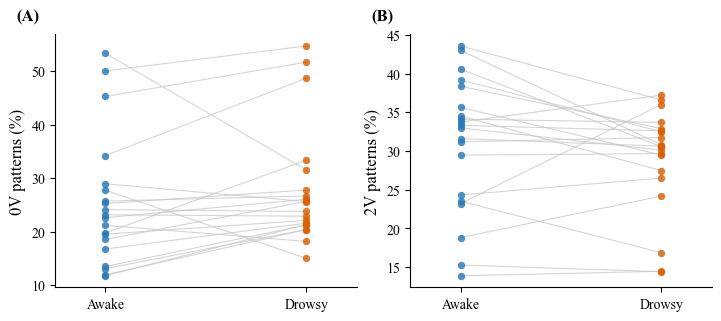

Saved symbolic_0V_2V_state_60s.pdf, symbolic_0V_2V_state_60s.svg, and symbolic_0V_2V_state_60s.png using Times New Roman.


In [3]:
# Cell 3 — Publication figure for 0V and 2V paired state effects.
def select_serif_font() -> str:
    """Select Times New Roman or the approved serif fallback."""
    available = {font.name for font in font_manager.fontManager.ttflist}
    for family in ("Times New Roman", "Liberation Serif", "DejaVu Serif"):
        if family in available:
            return family
    return "serif"


PLOT_FONT = select_serif_font()
mpl.rcParams.update(
    {
        "font.family": PLOT_FONT,
        "font.size": 11,
        "axes.labelsize": 12,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "svg.fonttype": "none",
    }
)
STATE_COLORS = {"Awake": "#2878B5", "Drowsy": "#D95F02"}
figure_metrics = (
    ("pct_0v", "0V patterns (%)", "(A)"),
    ("pct_2v", "2V patterns (%)", "(B)"),
)
fig, axes = plt.subplots(
    1, 2, figsize=(7.10, 3.10), constrained_layout=True
)
for axis, (metric, ylabel, panel) in zip(axes, figure_metrics):
    paired = session_state_summary.pivot(
        index="session_id", columns="state", values=metric
    ).reindex(index=sessions, columns=STATES)
    for session_id, row in paired.iterrows():
        axis.plot(
            [0, 1],
            [row["Awake"], row["Drowsy"]],
            color="0.78",
            linewidth=0.8,
            alpha=0.75,
            zorder=1,
        )
    axis.scatter(
        np.zeros(len(paired)),
        paired["Awake"],
        s=28,
        color=STATE_COLORS["Awake"],
        alpha=0.82,
        linewidths=0.0,
        zorder=2,
    )
    axis.scatter(
        np.ones(len(paired)),
        paired["Drowsy"],
        s=28,
        color=STATE_COLORS["Drowsy"],
        alpha=0.82,
        linewidths=0.0,
        zorder=2,
    )
    axis.set_xticks([0, 1], STATES)
    axis.set_xlim(-0.25, 1.25)
    axis.set_ylabel(ylabel)
    axis.text(
        -0.13,
        1.04,
        panel,
        transform=axis.transAxes,
        fontsize=12,
        fontweight="bold",
        ha="left",
        va="bottom",
    )
figure_pdf = OUTPUT_DIR / f"symbolic_0V_2V_state_{WINDOW_TAG}.pdf"
figure_svg = OUTPUT_DIR / f"symbolic_0V_2V_state_{WINDOW_TAG}.svg"
figure_png = OUTPUT_DIR / f"symbolic_0V_2V_state_{WINDOW_TAG}.png"
fig.savefig(figure_pdf, bbox_inches="tight")
fig.savefig(figure_svg, bbox_inches="tight")
fig.savefig(figure_png, dpi=600, bbox_inches="tight")
plt.show()
print(
    f"Saved {figure_pdf.name}, {figure_svg.name}, and {figure_png.name} "
    f"using {PLOT_FONT}."
)


In [4]:
# Cell 4 — Session table, compact evidence, and manuscript-ready conclusion.
session_symbolic_table = (
    session_state_summary.loc[
        :, ["session_id", "state", "pct_0v", "pct_2v"]
    ]
    .assign(
        _state_order=lambda frame: frame["state"].map(
            {"Awake": 0, "Drowsy": 1}
        )
    )
    .sort_values(["session_id", "_state_order"])
    .drop(columns="_state_order")
    .rename(
        columns={
            "session_id": "Session",
            "state": "State",
            "pct_0v": "Median 0V (%)",
            "pct_2v": "Median 2V (%)",
        }
    )
    .reset_index(drop=True)
)
if len(session_symbolic_table) != EXPECTED_SESSIONS * len(STATES):
    raise AssertionError("Expected exactly 40 session-state rows.")
print("Session-level relationship between 0V and 2V (40 rows):")
with pd.option_context("display.max_rows", 40):
    display(
        session_symbolic_table.style.format(
            {"Median 0V (%)": "{:.3f}", "Median 2V (%)": "{:.3f}"}
        ).hide(axis="index")
    )

def classify_symbolic_evidence(row: pd.Series) -> str:
    """Classify multiplicity-controlled symbolic evidence."""
    if row["BH_supported"]:
        return "BH-FDR supported"
    directional_majority = max(row["n_positive"], row["n_negative"]) > 10
    if row["CI_excludes_zero"] and directional_majority:
        return "Directionally consistent but weaker"
    return "No clear state effect"


final_symbolic = symbolic_comparison.copy()
final_symbolic["direction"] = np.where(
    final_symbolic["median_delta_drowsy_minus_awake"].gt(0.0),
    "Higher in Drowsy",
    np.where(
        final_symbolic["median_delta_drowsy_minus_awake"].lt(0.0),
        "Lower in Drowsy",
        "No median change",
    ),
)
final_symbolic["evidence_class"] = final_symbolic.apply(
    classify_symbolic_evidence, axis=1
)
final_symbolic["ci95"] = final_symbolic.apply(
    lambda row: f"[{row['ci95_low']:.3f}, {row['ci95_high']:.3f}]",
    axis=1,
)
final_table = final_symbolic[
    [
        "metric",
        "awake_median",
        "drowsy_median",
        "median_delta_drowsy_minus_awake",
        "ci95",
        "rank_biserial_r_rb",
        "q_BH",
        "direction",
        "evidence_class",
    ]
].rename(
    columns={
        "metric": "Metric",
        "awake_median": "Awake",
        "drowsy_median": "Drowsy",
        "median_delta_drowsy_minus_awake": "Median Delta",
        "ci95": "95% CI",
        "rank_biserial_r_rb": "r_rb",
        "q_BH": "q_BH",
        "direction": "Direction",
        "evidence_class": "Evidence class",
    }
)
final_table_path = (
    OUTPUT_DIR / f"symbolic_final_evidence_{WINDOW_TAG}.csv"
)
final_table.to_csv(final_table_path, index=False)


def metric_finding(metric: str) -> str:
    """Create one manuscript-ready symbolic metric sentence."""
    row = final_symbolic.loc[final_symbolic["metric"].eq(metric)].iloc[0]
    change = "increased" if row["median_delta_drowsy_minus_awake"] > 0 else "decreased"
    return (
        f"- {metric} {change} in Drowsy: median Delta="
        f"{row['median_delta_drowsy_minus_awake']:.3f} percentage points, "
        f"95% CI [{row['ci95_low']:.3f}, {row['ci95_high']:.3f}], "
        f"r_rb={row['rank_biserial_r_rb']:.3f}, q_BH={row['q_BH']:.4f}; "
        f"{row['evidence_class']}."
    )


primary_rows = final_symbolic.loc[final_symbolic["metric"].isin(["0V", "2V"])]
supported_primary = primary_rows.loc[primary_rows["BH_supported"], "metric"].tolist()
if supported_primary:
    opening = (
        "Drowsiness was associated with BH-FDR-supported changes in "
        + " and ".join(supported_primary)
        + " symbolic pattern composition."
    )
else:
    opening = (
        "Drowsiness showed directional changes in 0V and 2V symbolic "
        "pattern composition, without BH-FDR support."
    )
conclusion = "\n".join(
    [
        "## Symbolic analysis — Final finding",
        "",
        opening,
        "",
        metric_finding("0V"),
        metric_finding("2V"),
        "",
        "Paired session-level effects used median Drowsy-minus-Awake "
        "differences, 20,000-resample bootstrap confidence intervals, "
        "Wilcoxon signed-rank tests, rank-biserial effect sizes, and one "
        "BH-FDR correction family across 0V, 1V, and 2V.",
        "",
        "The shift in symbolic pattern composition provides complementary "
        "physiological context for the dynamical reorganization identified "
        "by Prediction, RQA, and LLE.",
        "",
        "These findings are consistent with altered autonomic modulation "
        "during drowsiness and compatible with a shift in autonomic balance. "
        "They are not direct evidence of a specific causal sympathetic or "
        "parasympathetic mechanism.",
    ]
)
conclusion_path = OUTPUT_DIR / f"symbolic_conclusion_{WINDOW_TAG}.md"
conclusion_path.write_text(conclusion + "\n", encoding="utf-8")
print(f"Saved {final_table_path.name} and {conclusion_path.name}.")
display(final_table)
display(Markdown(conclusion))


Session-level relationship between 0V and 2V (40 rows):


Session,State,Median 0V (%),Median 2V (%)
1,Awake,18.563,35.632
1,Drowsy,25.641,29.487
4,Awake,28.947,24.324
4,Drowsy,25.610,26.506
5,Awake,45.238,15.278
5,Drowsy,51.652,14.420
6,Awake,11.765,40.580
6,Drowsy,21.333,30.556
7,Awake,16.775,38.367
7,Drowsy,21.591,32.895


Saved symbolic_final_evidence_60s.csv and symbolic_conclusion_60s.md.


,Metric,Awake,Drowsy,Median Delta,95% CI,r_rb,q_BH,Direction,Evidence class
0,0V,22.887026,24.688032,4.043522,"[0.352, 7.184]",0.495238,0.113777,Higher in Drowsy,Directionally consistent but weaker
1,1V,42.471253,43.406224,0.408287,"[-1.468, 2.227]",0.180952,0.498009,Higher in Drowsy,No clear state effect
2,2V,33.154534,30.597879,-0.905473,"[-6.403, 0.371]",-0.457143,0.113777,Lower in Drowsy,No clear state effect


## Symbolic analysis — Final finding

Drowsiness showed directional changes in 0V and 2V symbolic pattern composition, without BH-FDR support.

- 0V increased in Drowsy: median Delta=4.044 percentage points, 95% CI [0.352, 7.184], r_rb=0.495, q_BH=0.1138; Directionally consistent but weaker.
- 2V decreased in Drowsy: median Delta=-0.905 percentage points, 95% CI [-6.403, 0.371], r_rb=-0.457, q_BH=0.1138; No clear state effect.

Paired session-level effects used median Drowsy-minus-Awake differences, 20,000-resample bootstrap confidence intervals, Wilcoxon signed-rank tests, rank-biserial effect sizes, and one BH-FDR correction family across 0V, 1V, and 2V.

The shift in symbolic pattern composition provides complementary physiological context for the dynamical reorganization identified by Prediction, RQA, and LLE.

These findings are consistent with altered autonomic modulation during drowsiness and compatible with a shift in autonomic balance. They are not direct evidence of a specific causal sympathetic or parasympathetic mechanism.

## Window size: 120 s

In [5]:
# Cell 1 — Load, restrict, and validate symbolic-analysis results.
from __future__ import annotations

import os
import re
import tempfile
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "matplotlib-ntsa-symbolic"))

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from matplotlib import font_manager
from scipy import stats


def locate_phase1(start: Path) -> Path:
    """Locate the phase1 directory."""
    for candidate in (start.resolve(), *start.resolve().parents):
        if candidate.name == "phase1" and (candidate / "results").is_dir():
            return candidate
        phase1 = candidate / "phase1"
        if (phase1 / "results").is_dir():
            return phase1
    raise FileNotFoundError("Could not locate phase1.")


PHASE1_DIR = locate_phase1(Path.cwd())
INPUT_DIR = PHASE1_DIR / "results" / "symbolic" / "processed"
WINDOW_SIZE_S = 120
OUTPUT_DIR = PHASE1_DIR / "outputs" / "symbolic" / str(WINDOW_SIZE_S)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
WINDOW_TAG = f"{WINDOW_SIZE_S}s"
INTEGRITY_PATH = OUTPUT_DIR / f"symbolic_integrity_{WINDOW_TAG}.csv"
FILE_PATTERN = re.compile(r"session_(\d+)_symbolic_analysis\.csv")
STATES = ("Awake", "Drowsy")
METRIC_COLUMNS = ("pct_0v", "pct_1v", "pct_2v")
METRIC_LABELS = {
    "pct_0v": "0V",
    "pct_1v": "1V",
    "pct_2v": "2V",
}
EXPECTED_SESSIONS = 20
COMPOSITION_TOLERANCE = 1e-8
integrity_rows: list[dict[str, object]] = []


def require(name: str, condition: bool, details: str) -> None:
    """Record an integrity check and fail loudly when needed."""
    integrity_rows.append(
        {"check": name, "passed": bool(condition), "details": details}
    )
    if not condition:
        pd.DataFrame(integrity_rows).to_csv(INTEGRITY_PATH, index=False)
        raise AssertionError(f"{name}: {details}")


file_map: dict[int, Path] = {}
for path in sorted(INPUT_DIR.glob("session_*_symbolic_analysis.csv")):
    match = FILE_PATTERN.fullmatch(path.name)
    require("recognized_filename", match is not None, path.name)
    session_id = int(match.group(1))
    require(
        f"unique_file_session_{session_id:02d}",
        session_id not in file_map,
        path.name,
    )
    file_map[session_id] = path
require(
    "exactly_20_symbolic_files",
    len(file_map) == EXPECTED_SESSIONS,
    f"found={len(file_map)}",
)
sessions = sorted(file_map)
required_columns = {
    "session_id",
    "representation",
    "window_uid",
    "window_size_s",
    "window_id",
    "state",
    "pct_0v",
    "pct_1v",
    "pct_2lv",
    "pct_2uv",
    "pct_2v",
    "symbolic_invariants_pass",
    "symbolic_valid",
    "analysis_included",
}
frames = []
for session_id in sessions:
    path = file_map[session_id]
    frame = pd.read_csv(path)
    missing = sorted(required_columns.difference(frame.columns))
    require(
        f"schema_session_{session_id:02d}",
        not missing,
        f"missing={missing}",
    )
    require(
        f"filename_session_match_{session_id:02d}",
        set(frame["session_id"].astype(int)) == {session_id},
        path.name,
    )
    frames.append(frame)
symbolic_all = pd.concat(frames, ignore_index=True)
primary_all = symbolic_all.loc[
    symbolic_all["representation"].str.casefold().eq("processed")
    & symbolic_all["window_size_s"].eq(WINDOW_SIZE_S)
    & symbolic_all["state"].isin(STATES)
].copy()
included_mask = primary_all["analysis_included"].astype(bool)
symbolic_data = primary_all.loc[included_mask].copy()
require(
    "all_20_sessions_in_primary_cohort",
    set(symbolic_data["session_id"].astype(int)) == set(sessions),
    f"found={symbolic_data['session_id'].nunique()}",
)
for state in STATES:
    state_sessions = symbolic_data.loc[
        symbolic_data["state"].eq(state), "session_id"
    ].nunique()
    require(
        f"both_states_{state.lower()}",
        state_sessions == EXPECTED_SESSIONS,
        f"sessions={state_sessions}",
    )
require(
    "unique_window_uid",
    not primary_all["window_uid"].duplicated().any(),
    f"duplicates={primary_all['window_uid'].duplicated().sum()}",
)
metric_values = symbolic_data[list(METRIC_COLUMNS)].to_numpy(dtype=float)
require(
    "finite_primary_symbolic_metrics",
    np.isfinite(metric_values).all(),
    f"nonfinite={int((~np.isfinite(metric_values)).sum())}",
)
require(
    "included_rows_are_symbolic_valid",
    symbolic_data["symbolic_valid"].astype(bool).all(),
    "all included rows",
)
require(
    "included_rows_pass_invariants",
    symbolic_data["symbolic_invariants_pass"].astype(bool).all(),
    "all included rows",
)
composition = symbolic_data[list(METRIC_COLUMNS)].sum(axis=1)
composition_error = np.abs(composition - 100.0)
require(
    "0V_1V_2V_sum_to_100_percent",
    composition_error.le(COMPOSITION_TOLERANCE).all(),
    f"max_abs_error={composition_error.max():.3g}",
)
split_error = np.abs(
    symbolic_data["pct_2lv"]
    + symbolic_data["pct_2uv"]
    - symbolic_data["pct_2v"]
)
require(
    "2V_equals_2LV_plus_2UV",
    split_error.le(COMPOSITION_TOLERANCE).all(),
    f"max_abs_error={split_error.max():.3g}",
)
window_counts = (
    symbolic_data.groupby(["session_id", "state"], sort=True)
    .size()
    .rename("n_windows")
    .reset_index()
)
integrity_report = pd.DataFrame(integrity_rows)
integrity_report.to_csv(INTEGRITY_PATH, index=False)
print(
    f"Symbolic integrity PASSED | files={len(file_map)} | "
    f"all rows={len(symbolic_all)} | primary {WINDOW_SIZE_S}-s="
    f"{len(primary_all)} | "
    f"included={len(symbolic_data)} | excluded={len(primary_all) - len(symbolic_data)}"
)
print(symbolic_data["state"].value_counts().reindex(STATES).to_string())
display(window_counts)
display(integrity_report.tail(10))


Symbolic integrity PASSED | files=20 | all rows=1544 | primary 120-s=405 | included=404 | excluded=1


state
Awake     269
Drowsy    135


,session_id,state,n_windows
0,1,Awake,11
1,1,Drowsy,1
2,4,Awake,13
3,4,Drowsy,7
4,5,Awake,14
5,5,Drowsy,8
6,6,Awake,14
7,6,Drowsy,7
8,7,Awake,17
9,7,Drowsy,5


,check,passed,details
80,filename_session_match_25,True,session_25_symbolic_analysis.csv
81,all_20_sessions_in_primary_cohort,True,found=20
82,both_states_awake,True,sessions=20
83,both_states_drowsy,True,sessions=20
84,unique_window_uid,True,duplicates=0
85,finite_primary_symbolic_metrics,True,nonfinite=0
86,included_rows_are_symbolic_valid,True,all included rows
87,included_rows_pass_invariants,True,all included rows
88,0V_1V_2V_sum_to_100_percent,True,max_abs_error=2.84e-14
89,2V_equals_2LV_plus_2UV,True,max_abs_error=1.42e-14


In [6]:
# Cell 2 — Session-level paired symbolic effects and formal inference.
BOOTSTRAP_RESAMPLES = 20_000
BOOTSTRAP_SEED = 20260902


def bootstrap_median_ci(
    values: np.ndarray, seed: int
) -> tuple[float, float]:
    """Return a percentile bootstrap CI for the paired median."""
    rng = np.random.default_rng(seed)
    indices = rng.integers(
        0, len(values), size=(BOOTSTRAP_RESAMPLES, len(values))
    )
    medians = np.median(values[indices], axis=1)
    low, high = np.percentile(medians, [2.5, 97.5])
    return float(low), float(high)


def paired_rank_biserial(values: np.ndarray) -> float:
    """Return matched-pairs signed-rank rank-biserial effect size."""
    nonzero = values[values != 0.0]
    if nonzero.size == 0:
        return 0.0
    ranks = stats.rankdata(np.abs(nonzero), method="average")
    positive = ranks[nonzero > 0.0].sum()
    negative = ranks[nonzero < 0.0].sum()
    return float((positive - negative) / (positive + negative))


def benjamini_hochberg(p_values: np.ndarray) -> np.ndarray:
    """Adjust one family of p-values with BH-FDR."""
    p_values = np.asarray(p_values, dtype=float)
    order = np.argsort(p_values, kind="stable")
    ordered = p_values[order]
    adjusted = ordered * len(ordered) / np.arange(1, len(ordered) + 1)
    adjusted = np.minimum.accumulate(adjusted[::-1])[::-1]
    result = np.empty_like(adjusted)
    result[order] = np.clip(adjusted, 0.0, 1.0)
    return result


session_state_summary = (
    symbolic_data.groupby(["session_id", "state"], sort=True)[
        list(METRIC_COLUMNS)
    ]
    .median()
    .reset_index()
)
if len(session_state_summary) != EXPECTED_SESSIONS * len(STATES):
    raise AssertionError("Expected one row per session and state.")
session_state_path = (
    OUTPUT_DIR / f"symbolic_session_state_{WINDOW_TAG}.csv"
)
session_state_summary.to_csv(session_state_path, index=False)

comparison_rows = []
paired_value_frames = []
for metric_index, metric in enumerate(METRIC_COLUMNS):
    paired = session_state_summary.pivot(
        index="session_id", columns="state", values=metric
    ).reindex(index=sessions, columns=STATES)
    if paired.isna().any().any() or len(paired) != EXPECTED_SESSIONS:
        raise AssertionError(f"Incomplete pairing for {metric}.")
    delta = (paired["Drowsy"] - paired["Awake"]).to_numpy(dtype=float)
    ci_low, ci_high = bootstrap_median_ci(
        delta, BOOTSTRAP_SEED + metric_index
    )
    if np.all(delta == 0.0):
        statistic, p_value = 0.0, 1.0
    else:
        test = stats.wilcoxon(
            delta,
            zero_method="wilcox",
            correction=False,
            alternative="two-sided",
            method="auto",
        )
        statistic, p_value = float(test.statistic), float(test.pvalue)
    comparison_rows.append(
        {
            "metric": METRIC_LABELS[metric],
            "source_column": metric,
            "n_paired_sessions": len(delta),
            "awake_median": float(paired["Awake"].median()),
            "drowsy_median": float(paired["Drowsy"].median()),
            "median_delta_drowsy_minus_awake": float(np.median(delta)),
            "ci95_low": ci_low,
            "ci95_high": ci_high,
            "bootstrap_resamples": BOOTSTRAP_RESAMPLES,
            "bootstrap_seed": BOOTSTRAP_SEED + metric_index,
            "wilcoxon_statistic": statistic,
            "raw_p_value": p_value,
            "rank_biserial_r_rb": paired_rank_biserial(delta),
            "n_positive": int(np.count_nonzero(delta > 0.0)),
            "n_negative": int(np.count_nonzero(delta < 0.0)),
            "n_zero": int(np.count_nonzero(delta == 0.0)),
        }
    )
    paired_frame = paired.reset_index()
    paired_frame["metric"] = METRIC_LABELS[metric]
    paired_frame["delta_drowsy_minus_awake"] = delta
    paired_value_frames.append(paired_frame)
symbolic_comparison = pd.DataFrame(comparison_rows)
if len(symbolic_comparison) != 3:
    raise AssertionError("The symbolic BH-FDR family must contain 3 tests.")
symbolic_comparison["q_BH"] = benjamini_hochberg(
    symbolic_comparison["raw_p_value"].to_numpy()
)
symbolic_comparison["BH_supported"] = symbolic_comparison["q_BH"].le(
    0.05
)
symbolic_comparison["CI_excludes_zero"] = (
    symbolic_comparison["ci95_low"].gt(0.0)
    | symbolic_comparison["ci95_high"].lt(0.0)
)
comparison_path = (
    OUTPUT_DIR / f"symbolic_state_comparison_{WINDOW_TAG}.csv"
)
symbolic_comparison.to_csv(comparison_path, index=False)
paired_values = pd.concat(paired_value_frames, ignore_index=True)
paired_values_path = (
    OUTPUT_DIR / f"symbolic_paired_values_{WINDOW_TAG}.csv"
)
paired_values.to_csv(paired_values_path, index=False)
print(
    "Formal choice: one BH-FDR family across 0V, 1V, and 2V. "
    "Interpretation remains focused on 0V and 2V."
)
print(
    f"Saved {comparison_path.name}, {session_state_path.name}, and "
    f"{paired_values_path.name}."
)
display(symbolic_comparison)


Formal choice: one BH-FDR family across 0V, 1V, and 2V. Interpretation remains focused on 0V and 2V.
Saved symbolic_state_comparison_120s.csv, symbolic_session_state_120s.csv, and symbolic_paired_values_120s.csv.


,metric,source_column,n_paired_sessions,awake_median,drowsy_median,median_delta_drowsy_minus_awake,ci95_low,ci95_high,bootstrap_resamples,bootstrap_seed,wilcoxon_statistic,raw_p_value,rank_biserial_r_rb,n_positive,n_negative,n_zero,q_BH,BH_supported,CI_excludes_zero
0,0V,pct_0v,20,27.403232,27.644587,2.318793,-2.635491,5.632720,20000,20260902,85.0,0.474905,0.190476,13,7,0,0.712358,False,False
1,1V,pct_1v,20,41.842368,41.938708,0.027477,-1.665801,2.127577,20000,20260903,102.0,0.927279,0.028571,10,10,0,0.927279,False,False
2,2V,pct_2v,20,30.341902,28.177656,-2.297454,-4.684168,1.784944,20000,20260904,78.0,0.329983,-0.257143,8,12,0,0.712358,False,False


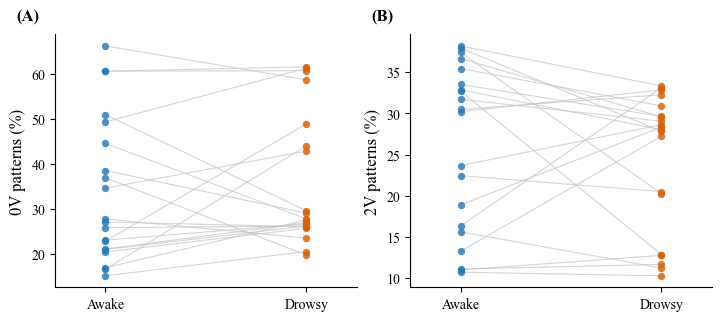

Saved symbolic_0V_2V_state_120s.pdf, symbolic_0V_2V_state_120s.svg, and symbolic_0V_2V_state_120s.png using Times New Roman.


In [7]:
# Cell 3 — Publication figure for 0V and 2V paired state effects.
def select_serif_font() -> str:
    """Select Times New Roman or the approved serif fallback."""
    available = {font.name for font in font_manager.fontManager.ttflist}
    for family in ("Times New Roman", "Liberation Serif", "DejaVu Serif"):
        if family in available:
            return family
    return "serif"


PLOT_FONT = select_serif_font()
mpl.rcParams.update(
    {
        "font.family": PLOT_FONT,
        "font.size": 11,
        "axes.labelsize": 12,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "svg.fonttype": "none",
    }
)
STATE_COLORS = {"Awake": "#2878B5", "Drowsy": "#D95F02"}
figure_metrics = (
    ("pct_0v", "0V patterns (%)", "(A)"),
    ("pct_2v", "2V patterns (%)", "(B)"),
)
fig, axes = plt.subplots(
    1, 2, figsize=(7.10, 3.10), constrained_layout=True
)
for axis, (metric, ylabel, panel) in zip(axes, figure_metrics):
    paired = session_state_summary.pivot(
        index="session_id", columns="state", values=metric
    ).reindex(index=sessions, columns=STATES)
    for session_id, row in paired.iterrows():
        axis.plot(
            [0, 1],
            [row["Awake"], row["Drowsy"]],
            color="0.78",
            linewidth=0.8,
            alpha=0.75,
            zorder=1,
        )
    axis.scatter(
        np.zeros(len(paired)),
        paired["Awake"],
        s=28,
        color=STATE_COLORS["Awake"],
        alpha=0.82,
        linewidths=0.0,
        zorder=2,
    )
    axis.scatter(
        np.ones(len(paired)),
        paired["Drowsy"],
        s=28,
        color=STATE_COLORS["Drowsy"],
        alpha=0.82,
        linewidths=0.0,
        zorder=2,
    )
    axis.set_xticks([0, 1], STATES)
    axis.set_xlim(-0.25, 1.25)
    axis.set_ylabel(ylabel)
    axis.text(
        -0.13,
        1.04,
        panel,
        transform=axis.transAxes,
        fontsize=12,
        fontweight="bold",
        ha="left",
        va="bottom",
    )
figure_pdf = OUTPUT_DIR / f"symbolic_0V_2V_state_{WINDOW_TAG}.pdf"
figure_svg = OUTPUT_DIR / f"symbolic_0V_2V_state_{WINDOW_TAG}.svg"
figure_png = OUTPUT_DIR / f"symbolic_0V_2V_state_{WINDOW_TAG}.png"
fig.savefig(figure_pdf, bbox_inches="tight")
fig.savefig(figure_svg, bbox_inches="tight")
fig.savefig(figure_png, dpi=600, bbox_inches="tight")
plt.show()
print(
    f"Saved {figure_pdf.name}, {figure_svg.name}, and {figure_png.name} "
    f"using {PLOT_FONT}."
)


In [8]:
# Cell 4 — Session table, compact evidence, and manuscript-ready conclusion.
session_symbolic_table = (
    session_state_summary.loc[
        :, ["session_id", "state", "pct_0v", "pct_2v"]
    ]
    .assign(
        _state_order=lambda frame: frame["state"].map(
            {"Awake": 0, "Drowsy": 1}
        )
    )
    .sort_values(["session_id", "_state_order"])
    .drop(columns="_state_order")
    .rename(
        columns={
            "session_id": "Session",
            "state": "State",
            "pct_0v": "Median 0V (%)",
            "pct_2v": "Median 2V (%)",
        }
    )
    .reset_index(drop=True)
)
if len(session_symbolic_table) != EXPECTED_SESSIONS * len(STATES):
    raise AssertionError("Expected exactly 40 session-state rows.")
print("Session-level relationship between 0V and 2V (40 rows):")
with pd.option_context("display.max_rows", 40):
    display(
        session_symbolic_table.style.format(
            {"Median 0V (%)": "{:.3f}", "Median 2V (%)": "{:.3f}"}
        ).hide(axis="index")
    )

def classify_symbolic_evidence(row: pd.Series) -> str:
    """Classify multiplicity-controlled symbolic evidence."""
    if row["BH_supported"]:
        return "BH-FDR supported"
    directional_majority = max(row["n_positive"], row["n_negative"]) > 10
    if row["CI_excludes_zero"] and directional_majority:
        return "Directionally consistent but weaker"
    return "No clear state effect"


final_symbolic = symbolic_comparison.copy()
final_symbolic["direction"] = np.where(
    final_symbolic["median_delta_drowsy_minus_awake"].gt(0.0),
    "Higher in Drowsy",
    np.where(
        final_symbolic["median_delta_drowsy_minus_awake"].lt(0.0),
        "Lower in Drowsy",
        "No median change",
    ),
)
final_symbolic["evidence_class"] = final_symbolic.apply(
    classify_symbolic_evidence, axis=1
)
final_symbolic["ci95"] = final_symbolic.apply(
    lambda row: f"[{row['ci95_low']:.3f}, {row['ci95_high']:.3f}]",
    axis=1,
)
final_table = final_symbolic[
    [
        "metric",
        "awake_median",
        "drowsy_median",
        "median_delta_drowsy_minus_awake",
        "ci95",
        "rank_biserial_r_rb",
        "q_BH",
        "direction",
        "evidence_class",
    ]
].rename(
    columns={
        "metric": "Metric",
        "awake_median": "Awake",
        "drowsy_median": "Drowsy",
        "median_delta_drowsy_minus_awake": "Median Delta",
        "ci95": "95% CI",
        "rank_biserial_r_rb": "r_rb",
        "q_BH": "q_BH",
        "direction": "Direction",
        "evidence_class": "Evidence class",
    }
)
final_table_path = (
    OUTPUT_DIR / f"symbolic_final_evidence_{WINDOW_TAG}.csv"
)
final_table.to_csv(final_table_path, index=False)


def metric_finding(metric: str) -> str:
    """Create one manuscript-ready symbolic metric sentence."""
    row = final_symbolic.loc[final_symbolic["metric"].eq(metric)].iloc[0]
    change = "increased" if row["median_delta_drowsy_minus_awake"] > 0 else "decreased"
    return (
        f"- {metric} {change} in Drowsy: median Delta="
        f"{row['median_delta_drowsy_minus_awake']:.3f} percentage points, "
        f"95% CI [{row['ci95_low']:.3f}, {row['ci95_high']:.3f}], "
        f"r_rb={row['rank_biserial_r_rb']:.3f}, q_BH={row['q_BH']:.4f}; "
        f"{row['evidence_class']}."
    )


primary_rows = final_symbolic.loc[final_symbolic["metric"].isin(["0V", "2V"])]
supported_primary = primary_rows.loc[primary_rows["BH_supported"], "metric"].tolist()
if supported_primary:
    opening = (
        "Drowsiness was associated with BH-FDR-supported changes in "
        + " and ".join(supported_primary)
        + " symbolic pattern composition."
    )
else:
    opening = (
        "Drowsiness showed directional changes in 0V and 2V symbolic "
        "pattern composition, without BH-FDR support."
    )
conclusion = "\n".join(
    [
        "## Symbolic analysis — Final finding",
        "",
        opening,
        "",
        metric_finding("0V"),
        metric_finding("2V"),
        "",
        "Paired session-level effects used median Drowsy-minus-Awake "
        "differences, 20,000-resample bootstrap confidence intervals, "
        "Wilcoxon signed-rank tests, rank-biserial effect sizes, and one "
        "BH-FDR correction family across 0V, 1V, and 2V.",
        "",
        "The shift in symbolic pattern composition provides complementary "
        "physiological context for the dynamical reorganization identified "
        "by Prediction, RQA, and LLE.",
        "",
        "These findings are consistent with altered autonomic modulation "
        "during drowsiness and compatible with a shift in autonomic balance. "
        "They are not direct evidence of a specific causal sympathetic or "
        "parasympathetic mechanism.",
    ]
)
conclusion_path = OUTPUT_DIR / f"symbolic_conclusion_{WINDOW_TAG}.md"
conclusion_path.write_text(conclusion + "\n", encoding="utf-8")
print(f"Saved {final_table_path.name} and {conclusion_path.name}.")
display(final_table)
display(Markdown(conclusion))


Session-level relationship between 0V and 2V (40 rows):


Session,State,Median 0V (%),Median 2V (%)
1,Awake,34.615,22.436
1,Drowsy,42.857,20.497
4,Awake,50.993,13.245
4,Drowsy,29.586,27.219
5,Awake,60.646,10.694
5,Drowsy,60.765,10.264
6,Awake,20.429,37.943
6,Drowsy,25.676,27.815
7,Awake,16.564,37.423
7,Drowsy,44.048,20.238


Saved symbolic_final_evidence_120s.csv and symbolic_conclusion_120s.md.


,Metric,Awake,Drowsy,Median Delta,95% CI,r_rb,q_BH,Direction,Evidence class
0,0V,27.403232,27.644587,2.318793,"[-2.635, 5.633]",0.190476,0.712358,Higher in Drowsy,No clear state effect
1,1V,41.842368,41.938708,0.027477,"[-1.666, 2.128]",0.028571,0.927279,Higher in Drowsy,No clear state effect
2,2V,30.341902,28.177656,-2.297454,"[-4.684, 1.785]",-0.257143,0.712358,Lower in Drowsy,No clear state effect


## Symbolic analysis — Final finding

Drowsiness showed directional changes in 0V and 2V symbolic pattern composition, without BH-FDR support.

- 0V increased in Drowsy: median Delta=2.319 percentage points, 95% CI [-2.635, 5.633], r_rb=0.190, q_BH=0.7124; No clear state effect.
- 2V decreased in Drowsy: median Delta=-2.297 percentage points, 95% CI [-4.684, 1.785], r_rb=-0.257, q_BH=0.7124; No clear state effect.

Paired session-level effects used median Drowsy-minus-Awake differences, 20,000-resample bootstrap confidence intervals, Wilcoxon signed-rank tests, rank-biserial effect sizes, and one BH-FDR correction family across 0V, 1V, and 2V.

The shift in symbolic pattern composition provides complementary physiological context for the dynamical reorganization identified by Prediction, RQA, and LLE.

These findings are consistent with altered autonomic modulation during drowsiness and compatible with a shift in autonomic balance. They are not direct evidence of a specific causal sympathetic or parasympathetic mechanism.

## Window size: 180 s

In [9]:
# Cell 1 — Load, restrict, and validate symbolic-analysis results.
from __future__ import annotations

import os
import re
import tempfile
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "matplotlib-ntsa-symbolic"))

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from matplotlib import font_manager
from scipy import stats


def locate_phase1(start: Path) -> Path:
    """Locate the phase1 directory."""
    for candidate in (start.resolve(), *start.resolve().parents):
        if candidate.name == "phase1" and (candidate / "results").is_dir():
            return candidate
        phase1 = candidate / "phase1"
        if (phase1 / "results").is_dir():
            return phase1
    raise FileNotFoundError("Could not locate phase1.")


PHASE1_DIR = locate_phase1(Path.cwd())
INPUT_DIR = PHASE1_DIR / "results" / "symbolic" / "processed"
WINDOW_SIZE_S = 180
OUTPUT_DIR = PHASE1_DIR / "outputs" / "symbolic" / str(WINDOW_SIZE_S)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
WINDOW_TAG = f"{WINDOW_SIZE_S}s"
INTEGRITY_PATH = OUTPUT_DIR / f"symbolic_integrity_{WINDOW_TAG}.csv"
FILE_PATTERN = re.compile(r"session_(\d+)_symbolic_analysis\.csv")
STATES = ("Awake", "Drowsy")
METRIC_COLUMNS = ("pct_0v", "pct_1v", "pct_2v")
METRIC_LABELS = {
    "pct_0v": "0V",
    "pct_1v": "1V",
    "pct_2v": "2V",
}
EXPECTED_SESSIONS = 20
COMPOSITION_TOLERANCE = 1e-8
integrity_rows: list[dict[str, object]] = []


def require(name: str, condition: bool, details: str) -> None:
    """Record an integrity check and fail loudly when needed."""
    integrity_rows.append(
        {"check": name, "passed": bool(condition), "details": details}
    )
    if not condition:
        pd.DataFrame(integrity_rows).to_csv(INTEGRITY_PATH, index=False)
        raise AssertionError(f"{name}: {details}")


file_map: dict[int, Path] = {}
for path in sorted(INPUT_DIR.glob("session_*_symbolic_analysis.csv")):
    match = FILE_PATTERN.fullmatch(path.name)
    require("recognized_filename", match is not None, path.name)
    session_id = int(match.group(1))
    require(
        f"unique_file_session_{session_id:02d}",
        session_id not in file_map,
        path.name,
    )
    file_map[session_id] = path
require(
    "exactly_20_symbolic_files",
    len(file_map) == EXPECTED_SESSIONS,
    f"found={len(file_map)}",
)
sessions = sorted(file_map)
required_columns = {
    "session_id",
    "representation",
    "window_uid",
    "window_size_s",
    "window_id",
    "state",
    "pct_0v",
    "pct_1v",
    "pct_2lv",
    "pct_2uv",
    "pct_2v",
    "symbolic_invariants_pass",
    "symbolic_valid",
    "analysis_included",
}
frames = []
for session_id in sessions:
    path = file_map[session_id]
    frame = pd.read_csv(path)
    missing = sorted(required_columns.difference(frame.columns))
    require(
        f"schema_session_{session_id:02d}",
        not missing,
        f"missing={missing}",
    )
    require(
        f"filename_session_match_{session_id:02d}",
        set(frame["session_id"].astype(int)) == {session_id},
        path.name,
    )
    frames.append(frame)
symbolic_all = pd.concat(frames, ignore_index=True)
primary_all = symbolic_all.loc[
    symbolic_all["representation"].str.casefold().eq("processed")
    & symbolic_all["window_size_s"].eq(WINDOW_SIZE_S)
    & symbolic_all["state"].isin(STATES)
].copy()
included_mask = primary_all["analysis_included"].astype(bool)
symbolic_data = primary_all.loc[included_mask].copy()
require(
    "all_20_sessions_in_primary_cohort",
    set(symbolic_data["session_id"].astype(int)) == set(sessions),
    f"found={symbolic_data['session_id'].nunique()}",
)
for state in STATES:
    state_sessions = symbolic_data.loc[
        symbolic_data["state"].eq(state), "session_id"
    ].nunique()
    require(
        f"both_states_{state.lower()}",
        state_sessions == EXPECTED_SESSIONS,
        f"sessions={state_sessions}",
    )
require(
    "unique_window_uid",
    not primary_all["window_uid"].duplicated().any(),
    f"duplicates={primary_all['window_uid'].duplicated().sum()}",
)
metric_values = symbolic_data[list(METRIC_COLUMNS)].to_numpy(dtype=float)
require(
    "finite_primary_symbolic_metrics",
    np.isfinite(metric_values).all(),
    f"nonfinite={int((~np.isfinite(metric_values)).sum())}",
)
require(
    "included_rows_are_symbolic_valid",
    symbolic_data["symbolic_valid"].astype(bool).all(),
    "all included rows",
)
require(
    "included_rows_pass_invariants",
    symbolic_data["symbolic_invariants_pass"].astype(bool).all(),
    "all included rows",
)
composition = symbolic_data[list(METRIC_COLUMNS)].sum(axis=1)
composition_error = np.abs(composition - 100.0)
require(
    "0V_1V_2V_sum_to_100_percent",
    composition_error.le(COMPOSITION_TOLERANCE).all(),
    f"max_abs_error={composition_error.max():.3g}",
)
split_error = np.abs(
    symbolic_data["pct_2lv"]
    + symbolic_data["pct_2uv"]
    - symbolic_data["pct_2v"]
)
require(
    "2V_equals_2LV_plus_2UV",
    split_error.le(COMPOSITION_TOLERANCE).all(),
    f"max_abs_error={split_error.max():.3g}",
)
window_counts = (
    symbolic_data.groupby(["session_id", "state"], sort=True)
    .size()
    .rename("n_windows")
    .reset_index()
)
integrity_report = pd.DataFrame(integrity_rows)
integrity_report.to_csv(INTEGRITY_PATH, index=False)
print(
    f"Symbolic integrity PASSED | files={len(file_map)} | "
    f"all rows={len(symbolic_all)} | primary {WINDOW_SIZE_S}-s="
    f"{len(primary_all)} | "
    f"included={len(symbolic_data)} | excluded={len(primary_all) - len(symbolic_data)}"
)
print(symbolic_data["state"].value_counts().reindex(STATES).to_string())
display(window_counts)
display(integrity_report.tail(10))


Symbolic integrity PASSED | files=20 | all rows=1544 | primary 180-s=238 | included=236 | excluded=2
state
Awake     160
Drowsy     76


,session_id,state,n_windows
0,1,Awake,6
1,1,Drowsy,1
2,4,Awake,8
3,4,Drowsy,5
4,5,Awake,9
5,5,Drowsy,3
6,6,Awake,8
7,6,Drowsy,5
8,7,Awake,11
9,7,Drowsy,1


,check,passed,details
80,filename_session_match_25,True,session_25_symbolic_analysis.csv
81,all_20_sessions_in_primary_cohort,True,found=20
82,both_states_awake,True,sessions=20
83,both_states_drowsy,True,sessions=20
84,unique_window_uid,True,duplicates=0
85,finite_primary_symbolic_metrics,True,nonfinite=0
86,included_rows_are_symbolic_valid,True,all included rows
87,included_rows_pass_invariants,True,all included rows
88,0V_1V_2V_sum_to_100_percent,True,max_abs_error=2.84e-14
89,2V_equals_2LV_plus_2UV,True,max_abs_error=7.11e-15


In [10]:
# Cell 2 — Session-level paired symbolic effects and formal inference.
BOOTSTRAP_RESAMPLES = 20_000
BOOTSTRAP_SEED = 20260902


def bootstrap_median_ci(
    values: np.ndarray, seed: int
) -> tuple[float, float]:
    """Return a percentile bootstrap CI for the paired median."""
    rng = np.random.default_rng(seed)
    indices = rng.integers(
        0, len(values), size=(BOOTSTRAP_RESAMPLES, len(values))
    )
    medians = np.median(values[indices], axis=1)
    low, high = np.percentile(medians, [2.5, 97.5])
    return float(low), float(high)


def paired_rank_biserial(values: np.ndarray) -> float:
    """Return matched-pairs signed-rank rank-biserial effect size."""
    nonzero = values[values != 0.0]
    if nonzero.size == 0:
        return 0.0
    ranks = stats.rankdata(np.abs(nonzero), method="average")
    positive = ranks[nonzero > 0.0].sum()
    negative = ranks[nonzero < 0.0].sum()
    return float((positive - negative) / (positive + negative))


def benjamini_hochberg(p_values: np.ndarray) -> np.ndarray:
    """Adjust one family of p-values with BH-FDR."""
    p_values = np.asarray(p_values, dtype=float)
    order = np.argsort(p_values, kind="stable")
    ordered = p_values[order]
    adjusted = ordered * len(ordered) / np.arange(1, len(ordered) + 1)
    adjusted = np.minimum.accumulate(adjusted[::-1])[::-1]
    result = np.empty_like(adjusted)
    result[order] = np.clip(adjusted, 0.0, 1.0)
    return result


session_state_summary = (
    symbolic_data.groupby(["session_id", "state"], sort=True)[
        list(METRIC_COLUMNS)
    ]
    .median()
    .reset_index()
)
if len(session_state_summary) != EXPECTED_SESSIONS * len(STATES):
    raise AssertionError("Expected one row per session and state.")
session_state_path = (
    OUTPUT_DIR / f"symbolic_session_state_{WINDOW_TAG}.csv"
)
session_state_summary.to_csv(session_state_path, index=False)

comparison_rows = []
paired_value_frames = []
for metric_index, metric in enumerate(METRIC_COLUMNS):
    paired = session_state_summary.pivot(
        index="session_id", columns="state", values=metric
    ).reindex(index=sessions, columns=STATES)
    if paired.isna().any().any() or len(paired) != EXPECTED_SESSIONS:
        raise AssertionError(f"Incomplete pairing for {metric}.")
    delta = (paired["Drowsy"] - paired["Awake"]).to_numpy(dtype=float)
    ci_low, ci_high = bootstrap_median_ci(
        delta, BOOTSTRAP_SEED + metric_index
    )
    if np.all(delta == 0.0):
        statistic, p_value = 0.0, 1.0
    else:
        test = stats.wilcoxon(
            delta,
            zero_method="wilcox",
            correction=False,
            alternative="two-sided",
            method="auto",
        )
        statistic, p_value = float(test.statistic), float(test.pvalue)
    comparison_rows.append(
        {
            "metric": METRIC_LABELS[metric],
            "source_column": metric,
            "n_paired_sessions": len(delta),
            "awake_median": float(paired["Awake"].median()),
            "drowsy_median": float(paired["Drowsy"].median()),
            "median_delta_drowsy_minus_awake": float(np.median(delta)),
            "ci95_low": ci_low,
            "ci95_high": ci_high,
            "bootstrap_resamples": BOOTSTRAP_RESAMPLES,
            "bootstrap_seed": BOOTSTRAP_SEED + metric_index,
            "wilcoxon_statistic": statistic,
            "raw_p_value": p_value,
            "rank_biserial_r_rb": paired_rank_biserial(delta),
            "n_positive": int(np.count_nonzero(delta > 0.0)),
            "n_negative": int(np.count_nonzero(delta < 0.0)),
            "n_zero": int(np.count_nonzero(delta == 0.0)),
        }
    )
    paired_frame = paired.reset_index()
    paired_frame["metric"] = METRIC_LABELS[metric]
    paired_frame["delta_drowsy_minus_awake"] = delta
    paired_value_frames.append(paired_frame)
symbolic_comparison = pd.DataFrame(comparison_rows)
if len(symbolic_comparison) != 3:
    raise AssertionError("The symbolic BH-FDR family must contain 3 tests.")
symbolic_comparison["q_BH"] = benjamini_hochberg(
    symbolic_comparison["raw_p_value"].to_numpy()
)
symbolic_comparison["BH_supported"] = symbolic_comparison["q_BH"].le(
    0.05
)
symbolic_comparison["CI_excludes_zero"] = (
    symbolic_comparison["ci95_low"].gt(0.0)
    | symbolic_comparison["ci95_high"].lt(0.0)
)
comparison_path = (
    OUTPUT_DIR / f"symbolic_state_comparison_{WINDOW_TAG}.csv"
)
symbolic_comparison.to_csv(comparison_path, index=False)
paired_values = pd.concat(paired_value_frames, ignore_index=True)
paired_values_path = (
    OUTPUT_DIR / f"symbolic_paired_values_{WINDOW_TAG}.csv"
)
paired_values.to_csv(paired_values_path, index=False)
print(
    "Formal choice: one BH-FDR family across 0V, 1V, and 2V. "
    "Interpretation remains focused on 0V and 2V."
)
print(
    f"Saved {comparison_path.name}, {session_state_path.name}, and "
    f"{paired_values_path.name}."
)
display(symbolic_comparison)


Formal choice: one BH-FDR family across 0V, 1V, and 2V. Interpretation remains focused on 0V and 2V.


Saved symbolic_state_comparison_180s.csv, symbolic_session_state_180s.csv, and symbolic_paired_values_180s.csv.


,metric,source_column,n_paired_sessions,awake_median,drowsy_median,median_delta_drowsy_minus_awake,ci95_low,ci95_high,bootstrap_resamples,bootstrap_seed,wilcoxon_statistic,raw_p_value,rank_biserial_r_rb,n_positive,n_negative,n_zero,q_BH,BH_supported,CI_excludes_zero
0,0V,pct_0v,20,29.084923,38.367189,4.583433,-1.117814,13.944000,20000,20260902,67.0,0.164957,0.361905,13,7,0,0.247436,False,False
1,1V,pct_1v,20,41.101812,40.747842,-0.055514,-4.314512,1.945251,20000,20260903,103.0,0.956329,-0.019048,10,10,0,0.956329,False,False
2,2V,pct_2v,20,27.299273,23.250009,-2.672681,-5.365693,-0.438496,20000,20260904,52.0,0.048441,-0.504762,5,15,0,0.145323,False,True


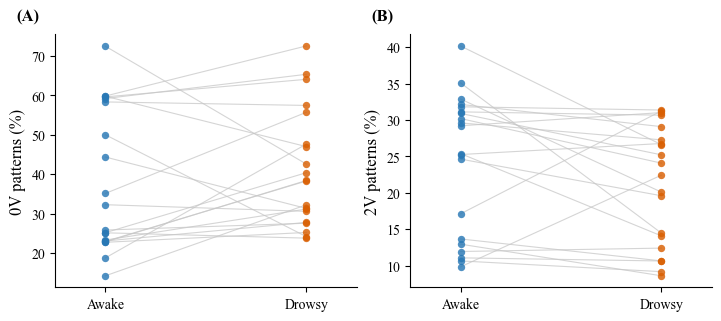

Saved symbolic_0V_2V_state_180s.pdf, symbolic_0V_2V_state_180s.svg, and symbolic_0V_2V_state_180s.png using Times New Roman.


In [11]:
# Cell 3 — Publication figure for 0V and 2V paired state effects.
def select_serif_font() -> str:
    """Select Times New Roman or the approved serif fallback."""
    available = {font.name for font in font_manager.fontManager.ttflist}
    for family in ("Times New Roman", "Liberation Serif", "DejaVu Serif"):
        if family in available:
            return family
    return "serif"


PLOT_FONT = select_serif_font()
mpl.rcParams.update(
    {
        "font.family": PLOT_FONT,
        "font.size": 11,
        "axes.labelsize": 12,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "svg.fonttype": "none",
    }
)
STATE_COLORS = {"Awake": "#2878B5", "Drowsy": "#D95F02"}
figure_metrics = (
    ("pct_0v", "0V patterns (%)", "(A)"),
    ("pct_2v", "2V patterns (%)", "(B)"),
)
fig, axes = plt.subplots(
    1, 2, figsize=(7.10, 3.10), constrained_layout=True
)
for axis, (metric, ylabel, panel) in zip(axes, figure_metrics):
    paired = session_state_summary.pivot(
        index="session_id", columns="state", values=metric
    ).reindex(index=sessions, columns=STATES)
    for session_id, row in paired.iterrows():
        axis.plot(
            [0, 1],
            [row["Awake"], row["Drowsy"]],
            color="0.78",
            linewidth=0.8,
            alpha=0.75,
            zorder=1,
        )
    axis.scatter(
        np.zeros(len(paired)),
        paired["Awake"],
        s=28,
        color=STATE_COLORS["Awake"],
        alpha=0.82,
        linewidths=0.0,
        zorder=2,
    )
    axis.scatter(
        np.ones(len(paired)),
        paired["Drowsy"],
        s=28,
        color=STATE_COLORS["Drowsy"],
        alpha=0.82,
        linewidths=0.0,
        zorder=2,
    )
    axis.set_xticks([0, 1], STATES)
    axis.set_xlim(-0.25, 1.25)
    axis.set_ylabel(ylabel)
    axis.text(
        -0.13,
        1.04,
        panel,
        transform=axis.transAxes,
        fontsize=12,
        fontweight="bold",
        ha="left",
        va="bottom",
    )
figure_pdf = OUTPUT_DIR / f"symbolic_0V_2V_state_{WINDOW_TAG}.pdf"
figure_svg = OUTPUT_DIR / f"symbolic_0V_2V_state_{WINDOW_TAG}.svg"
figure_png = OUTPUT_DIR / f"symbolic_0V_2V_state_{WINDOW_TAG}.png"
fig.savefig(figure_pdf, bbox_inches="tight")
fig.savefig(figure_svg, bbox_inches="tight")
fig.savefig(figure_png, dpi=600, bbox_inches="tight")
plt.show()
print(
    f"Saved {figure_pdf.name}, {figure_svg.name}, and {figure_png.name} "
    f"using {PLOT_FONT}."
)


In [12]:
# Cell 4 — Session table, compact evidence, and manuscript-ready conclusion.
session_symbolic_table = (
    session_state_summary.loc[
        :, ["session_id", "state", "pct_0v", "pct_2v"]
    ]
    .assign(
        _state_order=lambda frame: frame["state"].map(
            {"Awake": 0, "Drowsy": 1}
        )
    )
    .sort_values(["session_id", "_state_order"])
    .drop(columns="_state_order")
    .rename(
        columns={
            "session_id": "Session",
            "state": "State",
            "pct_0v": "Median 0V (%)",
            "pct_2v": "Median 2V (%)",
        }
    )
    .reset_index(drop=True)
)
if len(session_symbolic_table) != EXPECTED_SESSIONS * len(STATES):
    raise AssertionError("Expected exactly 40 session-state rows.")
print("Session-level relationship between 0V and 2V (40 rows):")
with pd.option_context("display.max_rows", 40):
    display(
        session_symbolic_table.style.format(
            {"Median 0V (%)": "{:.3f}", "Median 2V (%)": "{:.3f}"}
        ).hide(axis="index")
    )

def classify_symbolic_evidence(row: pd.Series) -> str:
    """Classify multiplicity-controlled symbolic evidence."""
    if row["BH_supported"]:
        return "BH-FDR supported"
    directional_majority = max(row["n_positive"], row["n_negative"]) > 10
    if row["CI_excludes_zero"] and directional_majority:
        return "Directionally consistent but weaker"
    return "No clear state effect"


final_symbolic = symbolic_comparison.copy()
final_symbolic["direction"] = np.where(
    final_symbolic["median_delta_drowsy_minus_awake"].gt(0.0),
    "Higher in Drowsy",
    np.where(
        final_symbolic["median_delta_drowsy_minus_awake"].lt(0.0),
        "Lower in Drowsy",
        "No median change",
    ),
)
final_symbolic["evidence_class"] = final_symbolic.apply(
    classify_symbolic_evidence, axis=1
)
final_symbolic["ci95"] = final_symbolic.apply(
    lambda row: f"[{row['ci95_low']:.3f}, {row['ci95_high']:.3f}]",
    axis=1,
)
final_table = final_symbolic[
    [
        "metric",
        "awake_median",
        "drowsy_median",
        "median_delta_drowsy_minus_awake",
        "ci95",
        "rank_biserial_r_rb",
        "q_BH",
        "direction",
        "evidence_class",
    ]
].rename(
    columns={
        "metric": "Metric",
        "awake_median": "Awake",
        "drowsy_median": "Drowsy",
        "median_delta_drowsy_minus_awake": "Median Delta",
        "ci95": "95% CI",
        "rank_biserial_r_rb": "r_rb",
        "q_BH": "q_BH",
        "direction": "Direction",
        "evidence_class": "Evidence class",
    }
)
final_table_path = (
    OUTPUT_DIR / f"symbolic_final_evidence_{WINDOW_TAG}.csv"
)
final_table.to_csv(final_table_path, index=False)


def metric_finding(metric: str) -> str:
    """Create one manuscript-ready symbolic metric sentence."""
    row = final_symbolic.loc[final_symbolic["metric"].eq(metric)].iloc[0]
    change = "increased" if row["median_delta_drowsy_minus_awake"] > 0 else "decreased"
    return (
        f"- {metric} {change} in Drowsy: median Delta="
        f"{row['median_delta_drowsy_minus_awake']:.3f} percentage points, "
        f"95% CI [{row['ci95_low']:.3f}, {row['ci95_high']:.3f}], "
        f"r_rb={row['rank_biserial_r_rb']:.3f}, q_BH={row['q_BH']:.4f}; "
        f"{row['evidence_class']}."
    )


primary_rows = final_symbolic.loc[final_symbolic["metric"].isin(["0V", "2V"])]
supported_primary = primary_rows.loc[primary_rows["BH_supported"], "metric"].tolist()
if supported_primary:
    opening = (
        "Drowsiness was associated with BH-FDR-supported changes in "
        + " and ".join(supported_primary)
        + " symbolic pattern composition."
    )
else:
    opening = (
        "Drowsiness showed directional changes in 0V and 2V symbolic "
        "pattern composition, without BH-FDR support."
    )
conclusion = "\n".join(
    [
        "## Symbolic analysis — Final finding",
        "",
        opening,
        "",
        metric_finding("0V"),
        metric_finding("2V"),
        "",
        "Paired session-level effects used median Drowsy-minus-Awake "
        "differences, 20,000-resample bootstrap confidence intervals, "
        "Wilcoxon signed-rank tests, rank-biserial effect sizes, and one "
        "BH-FDR correction family across 0V, 1V, and 2V.",
        "",
        "The shift in symbolic pattern composition provides complementary "
        "physiological context for the dynamical reorganization identified "
        "by Prediction, RQA, and LLE.",
        "",
        "These findings are consistent with altered autonomic modulation "
        "during drowsiness and compatible with a shift in autonomic balance. "
        "They are not direct evidence of a specific causal sympathetic or "
        "parasympathetic mechanism.",
    ]
)
conclusion_path = OUTPUT_DIR / f"symbolic_conclusion_{WINDOW_TAG}.md"
conclusion_path.write_text(conclusion + "\n", encoding="utf-8")
print(f"Saved {final_table_path.name} and {conclusion_path.name}.")
display(final_table)
display(Markdown(conclusion))


Session-level relationship between 0V and 2V (40 rows):


Session,State,Median 0V (%),Median 2V (%)
1,Awake,25.207,24.632
1,Drowsy,40.408,19.592
4,Awake,59.771,11.931
4,Drowsy,47.012,12.397
5,Awake,59.833,10.638
5,Drowsy,72.519,9.160
6,Awake,23.343,30.905
6,Drowsy,31.197,25.214
7,Awake,18.828,35.102
7,Drowsy,47.656,14.453


Saved symbolic_final_evidence_180s.csv and symbolic_conclusion_180s.md.


,Metric,Awake,Drowsy,Median Delta,95% CI,r_rb,q_BH,Direction,Evidence class
0,0V,29.084923,38.367189,4.583433,"[-1.118, 13.944]",0.361905,0.247436,Higher in Drowsy,No clear state effect
1,1V,41.101812,40.747842,-0.055514,"[-4.315, 1.945]",-0.019048,0.956329,Lower in Drowsy,No clear state effect
2,2V,27.299273,23.250009,-2.672681,"[-5.366, -0.438]",-0.504762,0.145323,Lower in Drowsy,Directionally consistent but weaker


## Symbolic analysis — Final finding

Drowsiness showed directional changes in 0V and 2V symbolic pattern composition, without BH-FDR support.

- 0V increased in Drowsy: median Delta=4.583 percentage points, 95% CI [-1.118, 13.944], r_rb=0.362, q_BH=0.2474; No clear state effect.
- 2V decreased in Drowsy: median Delta=-2.673 percentage points, 95% CI [-5.366, -0.438], r_rb=-0.505, q_BH=0.1453; Directionally consistent but weaker.

Paired session-level effects used median Drowsy-minus-Awake differences, 20,000-resample bootstrap confidence intervals, Wilcoxon signed-rank tests, rank-biserial effect sizes, and one BH-FDR correction family across 0V, 1V, and 2V.

The shift in symbolic pattern composition provides complementary physiological context for the dynamical reorganization identified by Prediction, RQA, and LLE.

These findings are consistent with altered autonomic modulation during drowsiness and compatible with a shift in autonomic balance. They are not direct evidence of a specific causal sympathetic or parasympathetic mechanism.

## Cross-window effect size and session consistency (inline only)

Compare the existing 60/120/180 s results on the **same 20 sessions**. For each session, Δ = median(Drowsy) − median(Awake), in percentage points.

- **Effect size:** matched-pairs rank-biserial `r_rb` and median session Δ. Bootstrap entire sessions jointly across all three windows (20,000 resamples), preserving their dependence. Compare each pair using the bootstrap distribution of the **difference between effect estimates**, rather than overlap of separate CIs.
- **Session consistency:** counts of positive/negative/zero Δ; exact sign agreement between windows; sessions with opposite nonzero signs; Spearman correlation of session Δ (descriptive, not an agreement coefficient).
- The 95% percentile CIs are **pointwise, exploratory, and not multiplicity-adjusted**. A difference CI containing zero does **not** establish equivalence. Practical equivalence requires prespecified acceptable differences for `r_rb` and Δ; no arbitrary margin is imposed here. These comparisons reflect the complete windowing/inclusion pipeline, including differing window counts, rather than identical time segments.

This section reads the existing CSV results and displays tables/figures inline; it does not export any files. The single forest plot shows median session differences and their unchanged 95% CIs for all three window sizes.

Method references: [paired bootstrap resampling](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.bootstrap.html), [Spearman rank correlation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.spearmanr.html).


In [1]:
# Load and align the saved results; this section can run independently.
from pathlib import Path
from itertools import combinations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from scipy import stats
from IPython.display import display, Markdown

def cw_locate_phase1():
    for parent in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
        for candidate in (parent, parent / "phase1"):
            if candidate.name == "phase1" and (candidate / "outputs/symbolic").is_dir():
                return candidate
    raise FileNotFoundError("Cannot locate phase1/outputs/symbolic")

CW_WINDOWS = (60, 120, 180)
CW_METRICS = ("0V", "1V", "2V")
CW_RESAMPLES = 20_000
CW_SEED = 20260909
cw_root = cw_locate_phase1() / "outputs/symbolic"
cw_paired = pd.concat([
    pd.read_csv(cw_root / str(w) / f"symbolic_paired_values_{w}s.csv")
    .assign(window_size_s=w) for w in CW_WINDOWS
], ignore_index=True)
cw_saved_effects = pd.concat([
    pd.read_csv(cw_root / str(w) / f"symbolic_state_comparison_{w}s.csv")
    .assign(window_size_s=w) for w in CW_WINDOWS
], ignore_index=True)
assert not cw_paired.duplicated(["session_id", "metric", "window_size_s"]).any()
assert set(cw_paired.metric) == set(CW_METRICS)
assert len(cw_paired) == 20 * 3 * 3
assert not cw_saved_effects.duplicated(["metric", "window_size_s"]).any()
assert len(cw_saved_effects) == 9
np.testing.assert_allclose(cw_paired.Drowsy - cw_paired.Awake,
                           cw_paired.delta_drowsy_minus_awake, atol=1e-12)
cw_delta = {
    metric: cw_paired.loc[cw_paired.metric.eq(metric)].pivot(
        index="session_id", columns="window_size_s",
        values="delta_drowsy_minus_awake"
    ).reindex(columns=CW_WINDOWS).sort_index()
    for metric in CW_METRICS
}
cw_sessions = cw_delta["0V"].index
for metric, frame in cw_delta.items():
    assert frame.shape == (20, 3), (metric, frame.shape)
    assert frame.index.equals(cw_sessions), metric
    assert np.isfinite(frame.to_numpy()).all(), metric
print("Aligned 20 identical sessions × 3 windows × 3 metrics; no missing pairs.")

def cw_rank_biserial(values):
    """Signed-rank r_rb along the last axis, omitting zero differences."""
    values = np.asarray(values, dtype=float)
    nonzero = values != 0.0
    ranks = stats.rankdata(np.where(nonzero, np.abs(values), np.nan),
                           axis=-1, method="average", nan_policy="omit")
    ranks = np.where(nonzero, ranks, 0.0)
    denominator = ranks.sum(axis=-1)
    return np.divide((ranks * np.sign(values)).sum(axis=-1), denominator,
                     out=np.zeros_like(denominator, dtype=float),
                     where=denominator != 0)

cw_indices = np.random.default_rng(CW_SEED).integers(
    0, len(cw_sessions), size=(CW_RESAMPLES, len(cw_sessions)))
cw_effect_rows, cw_difference_rows = [], []
for metric, frame in cw_delta.items():
    values = frame.to_numpy().T  # windows × sessions
    sample = values[:, cw_indices]  # same session indices for every window
    median_est = np.median(values, axis=-1)
    rrb_est = cw_rank_biserial(values)
    median_boot = np.median(sample, axis=-1)
    rrb_boot = cw_rank_biserial(sample)
    for j, window in enumerate(CW_WINDOWS):
        saved = cw_saved_effects.loc[
            cw_saved_effects.metric.eq(metric)
            & cw_saved_effects.window_size_s.eq(window)].iloc[0]
        np.testing.assert_allclose(
            [median_est[j], rrb_est[j]],
            [saved.median_delta_drowsy_minus_awake, saved.rank_biserial_r_rb],
            atol=1e-12)
        delta_ci = np.percentile(median_boot[j], [2.5, 97.5])
        rrb_ci = np.percentile(rrb_boot[j], [2.5, 97.5])
        cw_effect_rows.append(dict(
            metric=metric, window_s=window, median_delta_pp=median_est[j],
            delta_ci_low=delta_ci[0], delta_ci_high=delta_ci[1],
            r_rb=rrb_est[j], rrb_ci_low=rrb_ci[0], rrb_ci_high=rrb_ci[1],
            positive=int((values[j] > 0).sum()),
            negative=int((values[j] < 0).sum()), zero=int((values[j] == 0).sum())))
    for a, b in combinations(range(3), 2):
        dci = np.percentile(median_boot[b] - median_boot[a], [2.5, 97.5])
        rci = np.percentile(rrb_boot[b] - rrb_boot[a], [2.5, 97.5])
        cw_difference_rows.append(dict(
            metric=metric, contrast=f"{CW_WINDOWS[b]}s - {CW_WINDOWS[a]}s",
            difference_median_delta_pp=median_est[b] - median_est[a],
            delta_diff_ci_low=dci[0], delta_diff_ci_high=dci[1],
            delta_diff_ci_excludes_zero=bool(dci[0] > 0 or dci[1] < 0),
            difference_r_rb=rrb_est[b] - rrb_est[a],
            rrb_diff_ci_low=rci[0], rrb_diff_ci_high=rci[1],
            rrb_diff_ci_excludes_zero=bool(rci[0] > 0 or rci[1] < 0)))
cw_effects = pd.DataFrame(cw_effect_rows)
cw_effect_differences = pd.DataFrame(cw_difference_rows)
display(Markdown("### Effect sizes by window (95% paired-session bootstrap CIs)"))
display(cw_effects.style.format(precision=3).hide(axis="index"))
display(Markdown("### Direct differences between window effect estimates"))
display(cw_effect_differences.style.format(precision=3).hide(axis="index"))


Aligned 20 identical sessions × 3 windows × 3 metrics; no missing pairs.


### Effect sizes by window (95% paired-session bootstrap CIs)

metric,window_s,median_delta_pp,delta_ci_low,delta_ci_high,r_rb,rrb_ci_low,rrb_ci_high,positive,negative,zero
0V,60,4.044,0.352,7.184,0.495,0.019,0.905,14,6,0
0V,120,2.319,-2.635,5.633,0.190,-0.314,0.676,13,7,0
0V,180,4.583,-1.118,13.944,0.362,-0.143,0.810,13,7,0
1V,60,0.408,-1.468,2.227,0.181,-0.343,0.638,10,10,0
1V,120,0.027,-1.666,2.128,0.029,-0.467,0.514,10,10,0
1V,180,-0.056,-4.315,1.945,-0.019,-0.524,0.467,10,10,0
2V,60,-0.905,-6.403,0.371,-0.457,-0.848,0.029,7,13,0
2V,120,-2.297,-4.684,1.785,-0.257,-0.724,0.257,8,12,0
2V,180,-2.673,-5.366,-0.438,-0.505,-0.905,-0.029,5,15,0


### Direct differences between window effect estimates

metric,contrast,difference_median_delta_pp,delta_diff_ci_low,delta_diff_ci_high,delta_diff_ci_excludes_zero,difference_r_rb,rrb_diff_ci_low,rrb_diff_ci_high,rrb_diff_ci_excludes_zero
0V,120s - 60s,-1.725,-5.386,1.820,False,-0.305,-0.648,0.038,False
0V,180s - 60s,0.540,-4.069,8.329,False,-0.133,-0.419,0.095,False
0V,180s - 120s,2.265,-2.745,9.341,False,0.171,-0.143,0.514,False
1V,120s - 60s,-0.381,-1.985,1.764,False,-0.152,-0.533,0.276,False
1V,180s - 60s,-0.464,-3.690,1.961,False,-0.200,-0.705,0.286,False
1V,180s - 120s,-0.083,-3.837,2.151,False,-0.048,-0.552,0.438,False
2V,120s - 60s,-1.392,-3.241,2.816,False,0.200,-0.181,0.590,False
2V,180s - 60s,-1.767,-3.394,3.352,False,-0.048,-0.400,0.248,False
2V,180s - 120s,-0.375,-3.650,2.203,False,-0.248,-0.676,0.152,False


In [2]:
# Session-level sign agreement and rank consistency.
cw_agreement_rows, cw_consensus_rows = [], []
for metric, frame in cw_delta.items():
    values = frame.to_numpy()
    signs = np.sign(values)  # zeros are a separate category, as in the original analysis
    all_same = (signs == signs[:, [0]]).all(axis=1)
    has_reversal = (signs.min(axis=1) < 0) & (signs.max(axis=1) > 0)
    cw_consensus_rows.append(dict(
        metric=metric, same_sign_all_3=int(all_same.sum()),
        same_sign_all_3_pct=100 * all_same.mean(),
        positive_all_3=int((signs > 0).all(axis=1).sum()),
        negative_all_3=int((signs < 0).all(axis=1).sum()),
        zero_all_3=int((signs == 0).all(axis=1).sum()),
        any_sign_reversal=int(has_reversal.sum()),
        reversal_sessions=", ".join(map(str, frame.index[has_reversal])) or "none"))
    for a, b in combinations(range(3), 2):
        agree = signs[:, a] == signs[:, b]
        reverse = signs[:, a] * signs[:, b] < 0
        rho = (stats.spearmanr(values[:, a], values[:, b]).statistic
               if np.ptp(values[:, a]) > 0 and np.ptp(values[:, b]) > 0
               else np.nan)
        cw_agreement_rows.append(dict(
            metric=metric, windows=f"{CW_WINDOWS[a]}s / {CW_WINDOWS[b]}s",
            same_sign=int(agree.sum()), same_sign_pct=100 * agree.mean(),
            opposite_sign=int(reverse.sum()),
            zero_vs_nonzero=int((~agree & ~reverse).sum()),
            spearman_rho=rho,
            reversal_sessions=", ".join(map(str, frame.index[reverse])) or "none"))
cw_consensus = pd.DataFrame(cw_consensus_rows)
cw_agreement = pd.DataFrame(cw_agreement_rows)
display(Markdown("### Session consistency across all three windows (n = 20)"))
display(cw_consensus.style.format(precision=1).hide(axis="index"))
display(Markdown("### Pairwise session consistency"))
display(cw_agreement.style.format(precision=3).hide(axis="index"))

for metric, frame in cw_delta.items():
    table = frame.rename(columns={w: f"Delta {w}s (pp)" for w in CW_WINDOWS}).copy()
    signs = np.sign(frame.to_numpy())
    table["same_sign_all_3"] = (signs == signs[:, [0]]).all(axis=1)
    table["sign_reversal"] = (signs.min(axis=1) < 0) & (signs.max(axis=1) > 0)
    display(Markdown(f"#### {metric}: individual session changes"))
    display(table.style.format({f"Delta {w}s (pp)": "{:+.3f}" for w in CW_WINDOWS}))


### Session consistency across all three windows (n = 20)

metric,same_sign_all_3,same_sign_all_3_pct,positive_all_3,negative_all_3,zero_all_3,any_sign_reversal,reversal_sessions
0V,17,85.0,12,5,0,3,"15, 18, 23"
1V,11,55.0,5,6,0,9,"6, 8, 10, 11, 15, 17, 19, 22, 23"
2V,14,70.0,4,10,0,6,"10, 12, 13, 15, 19, 22"


### Pairwise session consistency

metric,windows,same_sign,same_sign_pct,opposite_sign,zero_vs_nonzero,spearman_rho,reversal_sessions
0V,60s / 120s,19,95.000,1,0,0.827,18
0V,60s / 180s,17,85.000,3,0,0.686,"15, 18, 23"
0V,120s / 180s,18,90.000,2,0,0.803,"15, 23"
1V,60s / 120s,16,80.000,4,0,0.663,"6, 11, 17, 22"
1V,60s / 180s,14,70.000,6,0,0.597,"8, 10, 15, 19, 22, 23"
1V,120s / 180s,12,60.000,8,0,0.608,"6, 8, 10, 11, 15, 17, 19, 23"
2V,60s / 120s,17,85.000,3,0,0.758,"12, 15, 22"
2V,60s / 180s,16,80.000,4,0,0.702,"10, 13, 19, 22"
2V,120s / 180s,15,75.000,5,0,0.755,"10, 12, 13, 15, 19"


#### 0V: individual session changes

window_size_s,Delta 60s (pp),Delta 120s (pp),Delta 180s (pp),same_sign_all_3,sign_reversal
session_id,,,,,
1,+7.078,+8.242,+15.202,True,False
4,-3.338,-21.408,-12.759,True,False
5,+6.414,+0.119,+12.686,True,False
6,+9.569,+5.247,+7.854,True,False
7,+4.816,+27.483,+28.828,True,False
8,+7.291,+5.405,+15.558,True,False
9,+3.420,+3.665,+4.712,True,False
10,+7.736,+5.233,+2.488,True,False
11,+8.430,+10.620,+17.985,True,False


#### 1V: individual session changes

window_size_s,Delta 60s (pp),Delta 120s (pp),Delta 180s (pp),same_sign_all_3,sign_reversal
session_id,,,,,
1,-1.232,-6.303,-9.274,True,False
4,+3.126,+10.119,+12.688,True,False
5,-2.197,-1.582,-12.223,True,False
6,+1.242,-0.740,+0.190,False,True
7,-0.218,-6.202,-5.834,True,False
8,+2.321,+4.085,-1.626,False,True
9,+1.035,+2.019,+0.797,True,False
10,+2.132,+0.906,-0.301,False,True
11,-2.021,+0.270,-4.264,False,True


#### 2V: individual session changes

window_size_s,Delta 60s (pp),Delta 120s (pp),Delta 180s (pp),same_sign_all_3,sign_reversal
session_id,,,,,
1,-6.144,-1.939,-5.040,True,False
4,+2.182,+13.974,+0.466,True,False
5,-0.857,-0.430,-1.478,True,False
6,-10.024,-10.129,-5.691,True,False
7,-5.472,-17.185,-20.649,True,False
8,-12.215,-4.861,-12.802,True,False
9,-2.873,-3.887,-3.052,True,False
10,-6.689,-4.530,+1.813,False,True
11,-6.980,-7.082,-13.566,True,False


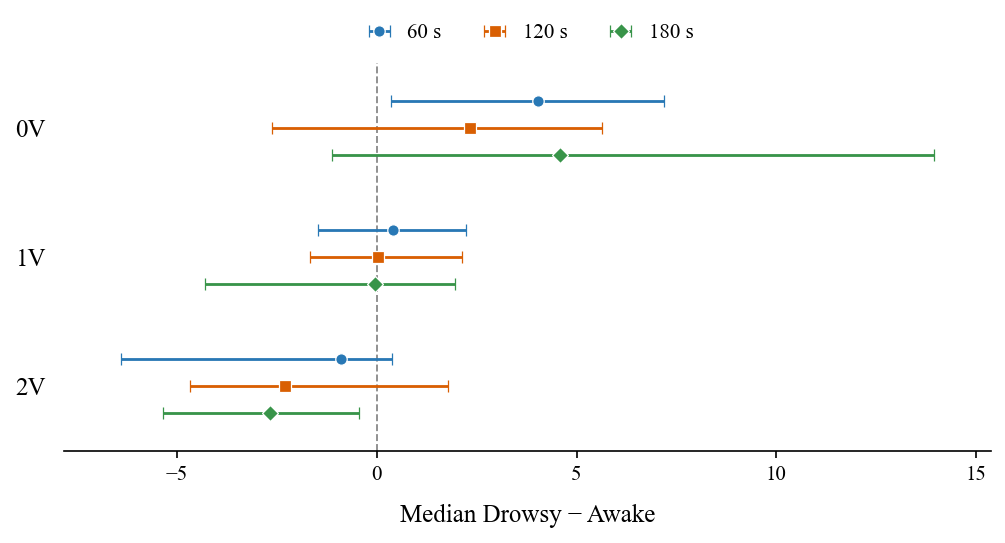

### Interpretation
- **0V** — 60 s: r_rb=+0.495, median Delta=+4.044 pp; 120 s: r_rb=+0.190, median Delta=+2.319 pp; 180 s: r_rb=+0.362, median Delta=+4.583 pp. Same sign across all three windows: **17/20 (85%)**; sessions with a sign reversal: 15, 18, 23.
- **1V** — 60 s: r_rb=+0.181, median Delta=+0.408 pp; 120 s: r_rb=+0.029, median Delta=+0.027 pp; 180 s: r_rb=-0.019, median Delta=-0.056 pp. Same sign across all three windows: **11/20 (55%)**; sessions with a sign reversal: 6, 8, 10, 11, 15, 17, 19, 22, 23.
- **2V** — 60 s: r_rb=-0.457, median Delta=-0.905 pp; 120 s: r_rb=-0.257, median Delta=-2.297 pp; 180 s: r_rb=-0.505, median Delta=-2.673 pp. Same sign across all three windows: **14/20 (70%)**; sessions with a sign reversal: 10, 12, 13, 15, 19, 22.

All direct r_rb difference CIs contain zero: these data do not clearly resolve window-dependent differences in r_rb.

All direct median Delta difference CIs contain zero: these data do not clearly resolve window-dependent differences in median Delta.

**The point estimates are not identical, and session consistency is assessed separately above. Equivalence is not established by CIs containing zero or by high correlation.**

In [3]:
# Single inline forest plot using the unchanged cross-window estimates and CIs.
cw_fonts = {font.name for font in font_manager.fontManager.ttflist}
cw_font = next((f for f in ("Times New Roman", "Liberation Serif", "DejaVu Serif")
                if f in cw_fonts), "serif")
cw_colors = {60: "#2878B5", 120: "#D95F02", 180: "#389449"}
cw_markers = {60: "o", 120: "s", 180: "D"}
with plt.rc_context({
    "font.family": cw_font, "font.size": 11,
    "axes.labelsize": 12, "xtick.labelsize": 10, "ytick.labelsize": 12,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.spines.left": False, "axes.linewidth": 0.8,
    "figure.facecolor": "white", "axes.facecolor": "white",
    "figure.dpi": 150,
}):
    fig = plt.figure(figsize=(7.10, 3.80))
    ax = fig.add_axes([0.10, 0.18, 0.87, 0.68])
    ax.axvline(0, color="0.55", linestyle="--", linewidth=0.9, zorder=0)
    for j, window in enumerate(CW_WINDOWS):
        rows = (cw_effects.loc[cw_effects.window_s.eq(window)]
                .set_index("metric").loc[list(CW_METRICS)])
        centers = rows["median_delta_pp"].to_numpy()
        low = rows["delta_ci_low"].to_numpy()
        high = rows["delta_ci_high"].to_numpy()
        assert np.all(low <= centers) and np.all(centers <= high)
        y = np.arange(len(CW_METRICS)) + (j - 1) * 0.21
        ax.errorbar(
            centers, y, xerr=np.vstack((centers - low, high - centers)),
            fmt=cw_markers[window], color=cw_colors[window],
            markersize=5.5, markeredgecolor="white", markeredgewidth=0.6,
            elinewidth=1.35, capsize=3, capthick=1.1,
            linestyle="none", label=f"{window} s", zorder=3,
        )
    ax.set_yticks(np.arange(len(CW_METRICS)), CW_METRICS)
    ax.set_ylim(len(CW_METRICS) - 1 + 0.50, -0.50)
    ax.set_xlabel("Median Drowsy − Awake", labelpad=9)
    ax.tick_params(axis="y", length=0, pad=9)
    ax.tick_params(axis="x", direction="out", length=3.5, width=0.8)
    ax.margins(x=0.07)
    ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.03),
              ncol=3, frameon=False, fontsize=10,
              handlelength=1.7, handletextpad=0.5, columnspacing=1.7,
              borderaxespad=0)
    assert len(fig.axes) == 1 and ax.get_title() == ""
    plt.show()

cw_findings = ["### Interpretation"]
for metric in CW_METRICS:
    rows = cw_effects.loc[cw_effects.metric.eq(metric)]
    consensus = cw_consensus.loc[cw_consensus.metric.eq(metric)].iloc[0]
    estimates = "; ".join(f"{int(r.window_s)} s: r_rb={r.r_rb:+.3f}, median Delta={r.median_delta_pp:+.3f} pp"
                          for r in rows.itertuples())
    cw_findings.append(
        f"- **{metric}** — {estimates}. Same sign across all three windows: "
        f"**{int(consensus.same_sign_all_3)}/20 ({consensus.same_sign_all_3_pct:.0f}%)**; "
        f"sessions with a sign reversal: {consensus.reversal_sessions}.")
for label, column in (("r_rb", "rrb_diff_ci_excludes_zero"),
                      ("median Delta", "delta_diff_ci_excludes_zero")):
    flagged = cw_effect_differences.loc[cw_effect_differences[column]]
    if flagged.empty:
        cw_findings.append(f"\nAll direct {label} difference CIs contain zero: these data do not clearly resolve window-dependent differences in {label}.")
    else:
        pairs = ", ".join(f"{r.metric} ({r.contrast})" for r in flagged.itertuples())
        cw_findings.append(f"\nPointwise {label} difference CIs exclude zero for: {pairs}. Treat these as exploratory, unadjusted comparisons.")
cw_findings.append("\n**The point estimates are not identical, and session consistency is assessed separately above. Equivalence is not established by CIs containing zero or by high correlation.**")
display(Markdown("\n".join(cw_findings)))
